# i2spec walkthrough: from potential curves to the I₂ spectrum

This notebook follows one calculation from start to finish with the published Hannover model: the Salumbides et al. (2008) potentials, the Bodermann et al. (2002) and Salumbides et al. (2006) hyperfine parameters, and the Tellinghuisen (2011) transition moment and continuum.

1. The X and B potential curves
2. Vibrational and rotational levels from the radial Schrödinger equation
3. Line positions
4. Hyperfine structure, against the BIPM tables
5. Line intensities: transition moment, Franck–Condon factors, populations
6. A Doppler-limited spectrum against the Salami & Ross FTS atlas
7. The continuum and the absolute cross section
8. Where the published model stops working

Run it from a checkout with `uv run --group notebook jupyter lab notebooks/walkthrough.ipynb`. The first run builds and caches the temperature-independent line list and the continuum, which takes about two minutes; after that it takes seconds. Sections 6 and 7 compare with third-party spectra in `data/external/`. Those files are not in the repository, and the comparisons are skipped when they are missing.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import i2spec
from i2spec import MHZ_PER_CM, RovibronicModel, load_potentials

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXTERNAL = ROOT / "data" / "external"
plt.rcParams.update({"figure.figsize": (8, 4.5), "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.formatter.useoffset": False})
print("i2spec", i2spec.__version__)

i2spec 0.0.1


## 1. Potential curves

The Hannover "X-representation" is a power series between two join points R_I and R_O:

V(R) = Σᵢ aᵢ ξⁱ,  with ξ = (R − R_m)/(R + b R_m).

* Inside R_I, an exponential wall A_I exp[−B_I (R − R_I)] continues the curve.
* Beyond R_O, the long-range form is D_e − Σ Cₙ/Rⁿ − A_O exp[−B_O (R − R_O)].
* The parameters are Table 1 of Salumbides et al. (2008). Energies are in cm⁻¹ above the X minimum.

X: D_e = 12547.34 cm⁻¹; joins at 2.4 and 3.3 Å
B: T_e = 15769.07 cm⁻¹, asymptote 20150.32 cm⁻¹ (well depth 4381.3 cm⁻¹); joins at 2.647 and 4.9 Å


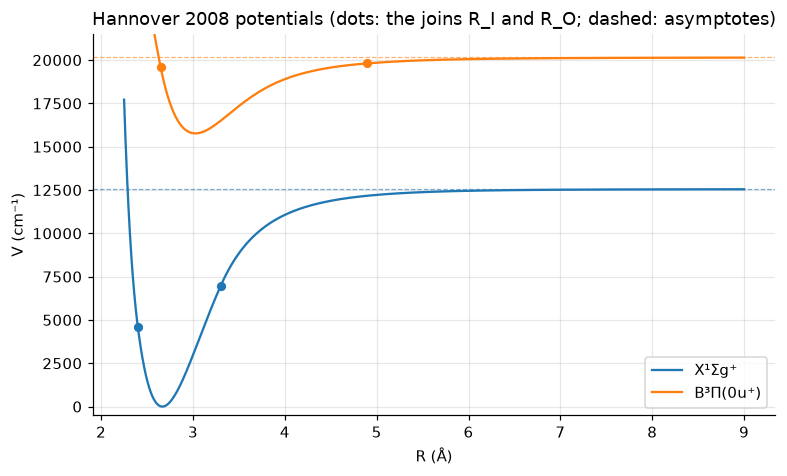

In [2]:
pots = load_potentials("hannover2008")
X, B = pots["X"], pots["B"]
R = np.linspace(2.25, 9.0, 3000)
fig, ax = plt.subplots()
for name, V, c in (("X¹Σg⁺", X, "C0"), ("B³Π(0u⁺)", B, "C1")):
    ax.plot(R, V(R), c, label=name)
    ax.plot([V.RI, V.RO], V(np.array([V.RI, V.RO])), "o", color=c, ms=5)
    ax.axhline(V.De, color=c, lw=0.8, ls="--", alpha=0.6)
ax.set(xlabel="R (Å)", ylabel="V (cm⁻¹)", ylim=(-500, 21500),
       title="Hannover 2008 potentials (dots: the joins R_I and R_O; dashed: asymptotes)")
ax.legend()
Te = B(np.linspace(2.9, 3.2, 3001)).min()
print(f"X: D_e = {X.De:.2f} cm⁻¹; joins at {X.RI} and {X.RO} Å")
print(f"B: T_e = {Te:.2f} cm⁻¹, asymptote {B.De:.2f} cm⁻¹ (well depth {B.De - Te:.1f} cm⁻¹); joins at {B.RI} and {B.RO} Å")

The pieces meet with equal value and slope, but the curvature jumps (the curve is C¹, not C²). That matters numerically. A grid method that ignores the joins converges slowly for levels whose wavefunctions reach them. That is why i2spec's default solver is a B-spline basis with knots placed at the joins.

In [3]:
for name, V in (("X", X), ("B", B)):
    outer_value = V.dispersion(V.RO) - V.AO
    outer_slope = sum(n * c / V.RO ** (n + 1) for n, c in V.C.items()) + V.AO * V.BO
    print(f"{name} at R_I = {V.RI} Å: value {V.AI:12.4f} | {V.series(V.RI):12.4f} cm⁻¹, "
          f"slope {-V.BI * V.AI:10.2f} | {V.series_derivative(V.RI):10.2f} cm⁻¹/Å   (wall | series)")
    print(f"{name} at R_O = {V.RO} Å: value {V.series(V.RO):12.4f} | {outer_value:12.4f} cm⁻¹, "
          f"slope {V.series_derivative(V.RO):10.2f} | {outer_slope:10.2f} cm⁻¹/Å   (series | long range)")

X at R_I = 2.4 Å: value    4580.9329 |    4580.9329 cm⁻¹, slope  -41305.50 |  -41305.50 cm⁻¹/Å   (wall | series)
X at R_O = 3.3 Å: value    6950.2430 |    6950.2430 cm⁻¹, slope   12042.21 |   12042.21 cm⁻¹/Å   (series | long range)
B at R_I = 2.647 Å: value   19605.2690 |   19605.2689 cm⁻¹, slope  -26929.85 |  -26929.83 cm⁻¹/Å   (wall | series)
B at R_O = 4.9 Å: value   19810.4523 |   19810.4523 cm⁻¹, slope     400.91 |     400.91 cm⁻¹/Å   (series | long range)


## 2. Vibrational and rotational levels

Each state's levels solve the radial equation

[−ħ²/2μ d²/dR² + V(R) + (1 + α(R)) ħ² J(J+1)/(2μR²) + V_corr(R)] χ = E χ.

* α(R) and V_corr(R) are the Born–Oppenheimer corrections of Salumbides et al. (2008).
* V_corr vanishes for ¹²⁷I₂, the reference isotopologue.
* `RovibronicModel` uses the B-spline solver; its levels are converged to about 0.1 kHz.

X(v=0, J=0) lies 107.100 cm⁻¹ above the X minimum
T₀ = B(0,0) − X(0,0) = 15724.587 cm⁻¹;  ΔG(½): X 213.301, B 124.156 cm⁻¹


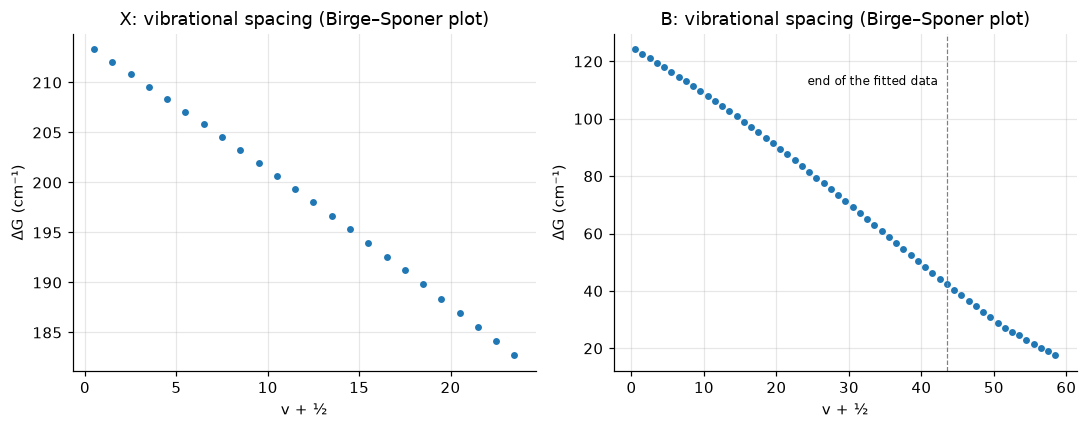

In [4]:
m = RovibronicModel("127I2")
e00 = m.energy("X", 0, 0)
GX = np.array([m.energy("X", v, 0) - e00 for v in range(25)])
GB = np.array([m.energy("B", v, 0) - e00 for v in range(60)])
print(f"X(v=0, J=0) lies {e00:.3f} cm⁻¹ above the X minimum")
print(f"T₀ = B(0,0) − X(0,0) = {GB[0]:.3f} cm⁻¹;  ΔG(½): X {GX[1] - GX[0]:.3f}, B {GB[1] - GB[0]:.3f} cm⁻¹")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, G, name in ((axes[0], GX, "X"), (axes[1], GB, "B")):
    ax.plot(np.arange(len(G) - 1) + 0.5, np.diff(G), "o", ms=3.5)
    ax.set(xlabel="v + ½", ylabel="ΔG (cm⁻¹)", title=f"{name}: vibrational spacing (Birge–Sponer plot)")
axes[1].axvline(43.5, color="0.5", ls="--", lw=0.8)
axes[1].annotate("end of the fitted data", (43.5, np.diff(GB).max() * 0.9), xytext=(-6, 0),
                 textcoords="offset points", ha="right", fontsize=8)
fig.tight_layout()

The wavefunctions and the transition matrix elements later on come from a sinc-DVR on a grid shared by X and B (`intensity_model`). Each |ψ_v|² below is drawn at the level's energy.

[(2.4, 6.5),
 (-300.0, 21000.0),
 Text(0.5, 0, 'R (Å)'),
 Text(0, 0.5, 'energy (cm⁻¹)'),
 Text(0.5, 1.0, 'Vibrational probability densities |ψ_v(R)|²')]

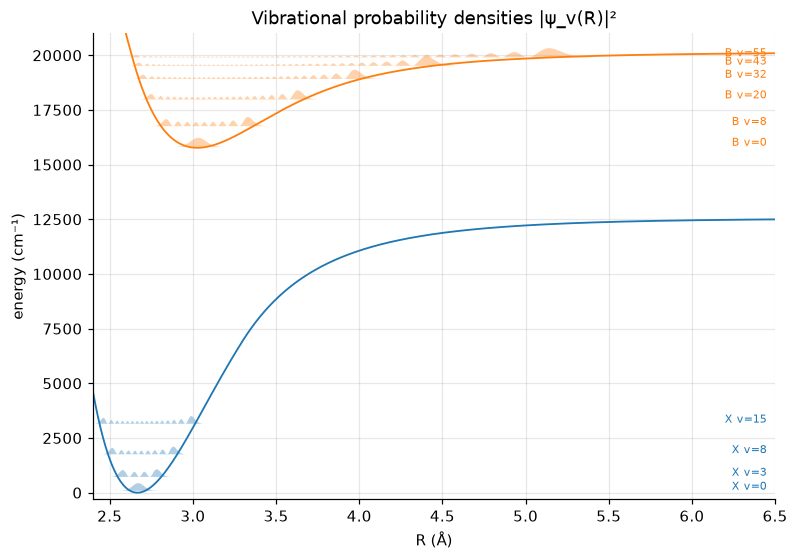

In [5]:
from i2spec.intensity import intensity_model

mi = intensity_model("127I2")
Rg = mi.states["B"].R
Rp = np.linspace(2.4, 6.5, 2000)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(Rp, X(Rp), "C0", lw=1.2)
ax.plot(Rp, B(Rp), "C1", lw=1.2)
for state, levels, colour, height in (("X", (0, 3, 8, 15), "C0", 350), ("B", (0, 8, 20, 32, 43, 55), "C1", 420)):
    E, vec = mi.states[state].states(0)
    for v in levels:
        p = vec[:, v] ** 2
        ax.fill_between(Rg, E[v], E[v] + height * p / p.max(), color=colour, alpha=0.35, lw=0)
        ax.text(6.45, E[v] + 30, f"{state} v={v}", fontsize=7, ha="right", color=colour)
ax.set(xlim=(2.4, 6.5), ylim=(-300, 21000), xlabel="R (Å)", ylabel="energy (cm⁻¹)",
       title="Vibrational probability densities |ψ_v(R)|²")

In [6]:
J = np.arange(0, 200, 10)
x = J * (J + 1)
for name, E in (("X, v″ = 0 ", [m.energy("X", 0, j) for j in J]), ("B, v′ = 32", [m.energy("B", 32, j) for j in J])):
    E = np.array(E)
    c = np.polyfit(x, E - E[0], 3)
    print(f"{name}: B_v = {c[2]:.6f} cm⁻¹, D_v = {-c[1]:.3e} cm⁻¹  (fit of E(J) − E(0) to J(J+1) up to J = 190)")

X, v″ = 0 : B_v = 0.037311 cm⁻¹, D_v = 4.547e-09 cm⁻¹  (fit of E(J) − E(0) to J(J+1) up to J = 190)
B, v′ = 32: B_v = 0.022272 cm⁻¹, D_v = 1.585e-08 cm⁻¹  (fit of E(J) − E(0) to J(J+1) up to J = 190)


## 3. Line positions

A B–X line lies at ν = E_B(v′, J′) − E_X(v″, J″), with J′ = J″ + 1 (R branch) or J″ − 1 (P branch). Q lines are forbidden for 0u⁺–0g⁺. The 32–0 band below contains R(56) 32-0, the line of the 532 nm frequency standard.

R(56) 32-0: 18788.3356 cm⁻¹ = 563,260,130.9 MHz (532.2451 nm, vacuum), hyperfine-free


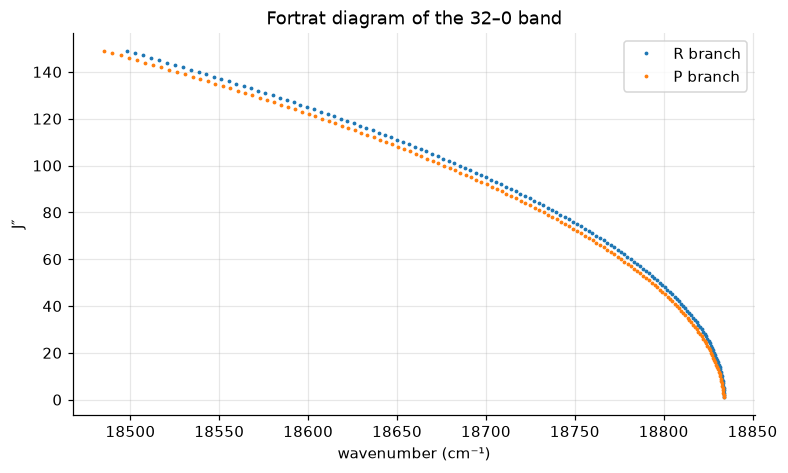

In [7]:
J = np.arange(1, 150)
nuR = np.array([m.transition(32, 0, j, "R") for j in J])
nuP = np.array([m.transition(32, 0, j, "P") for j in J])
fig, ax = plt.subplots()
ax.plot(nuR, J, ".", ms=3, label="R branch")
ax.plot(nuP, J, ".", ms=3, label="P branch")
ax.set(xlabel="wavenumber (cm⁻¹)", ylabel="J″", title="Fortrat diagram of the 32–0 band")
ax.legend()
nu = m.transition(32, 0, 56, "R")
print(f"R(56) 32-0: {nu:.4f} cm⁻¹ = {nu * MHZ_PER_CM:,.1f} MHz ({1e7 / nu:.4f} nm, vacuum), hyperfine-free")

## 4. Hyperfine structure

In each state, H = eqQ·H_EQ + C·I·J + d·H_TSS + δ·I₁·I₂. It is diagonalized in the coupled basis |J, (I₁I₂)I; F⟩, including the couplings to J ± 2.

* The ¹²⁷I₂ parameters are Bodermann et al. (2002).
* ¹²⁹I₂ and ¹²⁷I¹²⁹I use Salumbides et al. (2006), with separate quadrupole and spin–rotation constants per nucleus.
* The labels a1, a2, … number the main (ΔF = ΔJ) components by frequency.
* The crosses are the BIPM table for R(56) 32-0, placed relative to the model's a10.

model − BIPM (kHz): a1 +4.7, a2 +24.1, a5 -53.7, a6 +24.9, a7 +18.6, a8 -20.3, a9 -33.2, a11 +6.9, a12 +7.8, a13 -10.7, a14 -31.4, a15 -11.7
absolute a10: model 563,260,225.516 MHz; CIPM 563,260,223.513 MHz; difference +2.003 MHz


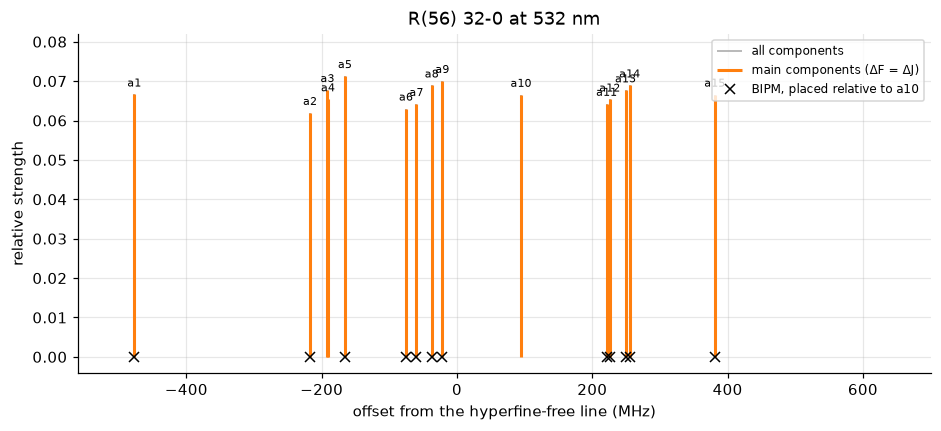

In [8]:
from i2spec.observations import DATA_DIR, Predictor, load_dataset

nu0, comps = m.hyperfine_components(32, 0, 56, "R")
main = {c.label: c for c in comps if c.label}
bipm = load_dataset(DATA_DIR / "bipm2012a")
measured = {o.component: o.value for o in bipm.observations
            if str(o.line) == "127I2 R(56) 32-0" and o.kind == "interval" and o.ref_line is None}
a10 = main["a10"].offset

fig, ax = plt.subplots(figsize=(10, 4))
ax.vlines([c.offset for c in comps], 0, [c.strength for c in comps], color="0.65", lw=1, label="all components")
ax.vlines([c.offset for c in main.values()], 0, [c.strength for c in main.values()], color="C1", lw=2,
          label="main components (ΔF = ΔJ)")
for label, c in main.items():
    ax.text(c.offset, c.strength + 0.002, label, ha="center", fontsize=7)
ax.plot([a10 + v for v in measured.values()], np.zeros(len(measured)), "kx", ms=7, label="BIPM, placed relative to a10")
ax.set(xlabel="offset from the hyperfine-free line (MHz)", ylabel="relative strength", title="R(56) 32-0 at 532 nm",
       xlim=(-560, 700), ylim=(-0.004, 0.082))
ax.legend(loc="upper right", fontsize=8)
print("model − BIPM (kHz):", ", ".join(f"{k} {1e3 * ((main[k].offset - a10) - v):+.1f}" for k, v in measured.items()))
print(f"absolute a10: model {nu0 + a10:,.3f} MHz; CIPM 563,260,223.513 MHz; difference {nu0 + a10 - 563260223.513:+.3f} MHz")

The same comparison for an isotopologue, ¹²⁹I₂ P(54) 8-4 at 633 nm. It uses `i2spec.observations`, the format in which all 693 BIPM values are stored (`docs/design/observations.md`).

rms 45 kHz over the 10 components measured to ≤ 100 kHz; the others have u = 1–2 MHz


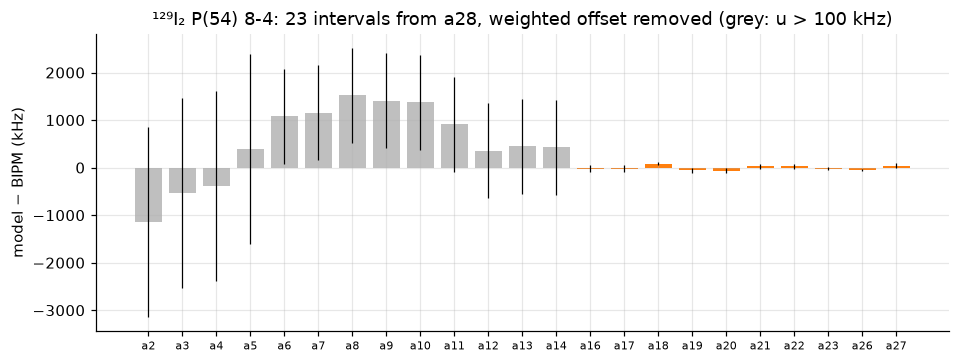

In [9]:
pred = Predictor()
ds = load_dataset(DATA_DIR / "bipm2003a")
obs = [o for o in ds.observations if str(o.line) == "129I2 P(54) 8-4" and o.kind == "interval" and o.ref_line is None]
diff = np.array([pred(o) - o.value for o in obs]) * 1e3
u = np.array([1e3 * o.uncertainty for o in obs])
diff -= np.average(diff, weights=u ** -2)  # the reference component's own error is a common offset
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar([o.component for o in obs], diff, color=["C1" if x <= 100 else "0.75" for x in u])
ax.errorbar(range(len(obs)), diff, yerr=u, fmt="none", ecolor="k", lw=0.8)
ax.set(ylabel="model − BIPM (kHz)",
       title=f"¹²⁹I₂ P(54) 8-4: {len(obs)} intervals from {obs[0].ref_component}, weighted offset removed (grey: u > 100 kHz)")
ax.tick_params(axis="x", labelsize=7)
good = u <= 100
print(f"rms {diff[good].std():.0f} kHz over the {good.sum()} components measured to ≤ 100 kHz; "
      f"the others have u = {u[~good].min() / 1e3:.0f}–{u[~good].max() / 1e3:.0f} MHz")

## 5. Line intensities

The integrated cross section of a line is

S = (2π²ν / 3ε₀hc) · s_J′J″/(2J″+1) · |⟨v′J′|μ(R)|v″J″⟩|² · f(v″, J″).

* μ(R) is the transition moment of Tellinghuisen (2011).
* The Hönl–London factor s is J″ + 1 for R lines and J″ for P lines.
* f is the Boltzmann population, including the nuclear-spin weights: 15 for even and 21 for odd J″ in ¹²⁷I₂.

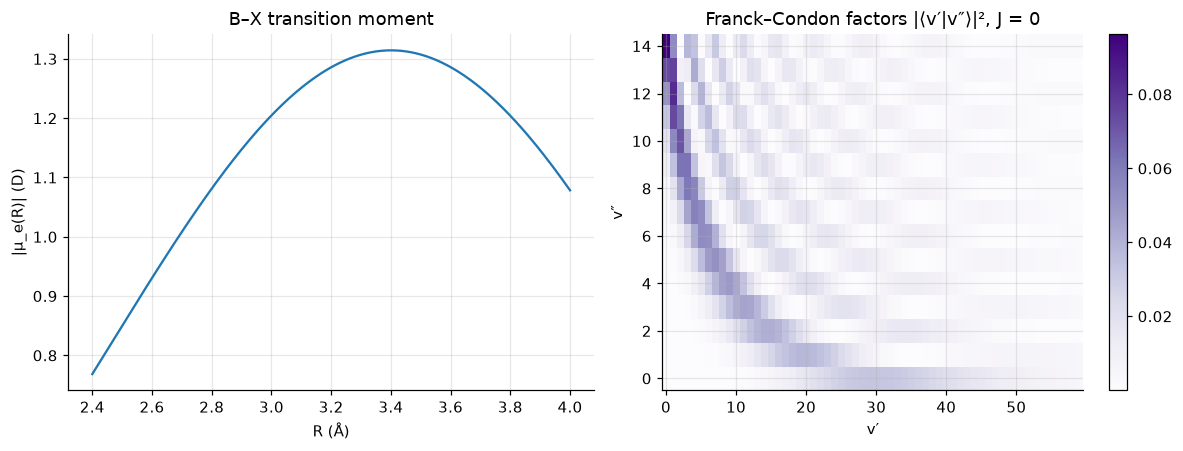

In [10]:
from i2spec.intensity import mu_tellinghuisen2011

Ex, cx = mi.states["X"].states(0)
Eb, cb = mi.states["B"].states(0)
fcf = (cb.T @ cx) ** 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
r = np.linspace(2.4, 4.0, 300)
axes[0].plot(r, mu_tellinghuisen2011(r))
axes[0].set(xlabel="R (Å)", ylabel="|μ_e(R)| (D)", title="B–X transition moment")
im = axes[1].imshow(fcf[:60, :15].T, origin="lower", aspect="auto", cmap="Purples", extent=(-0.5, 59.5, -0.5, 14.5))
axes[1].set(xlabel="v′", ylabel="v″", title="Franck–Condon factors |⟨v′|v″⟩|², J = 0")
fig.colorbar(im, ax=axes[1])
fig.tight_layout()

The master line list stores every B–X line in temperature-independent form, S(T) = S₀ exp(−c₂E″/T)/Q(T). It covers 11 000–20 100 cm⁻¹ and every line stronger than 10⁻²⁷ cm at some temperature between 200 and 600 K. It is cached in `~/.cache/i2spec` after the first build.

1,081,941 lines


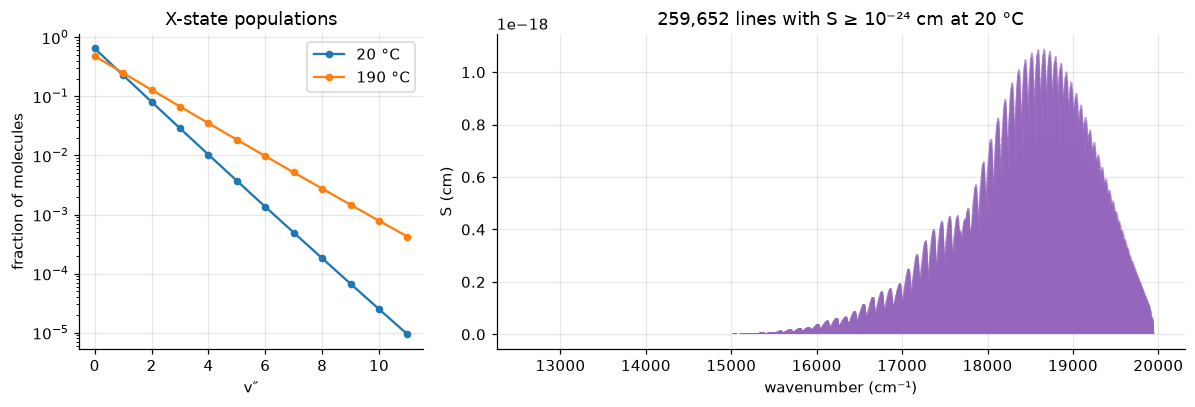

In [11]:
from i2spec.intensity import C2, master_line_list, nuclear_spin_weight

master = master_line_list(mi, 11000.0, 20100.0, T_range=(200.0, 600.0), S_min=1e-27)
print(f"{len(master):,} lines")
J = np.arange(master.x_levels.shape[0])
g = np.array([nuclear_spin_weight(j, "127I2") for j in J]) * (2 * J + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 2]})
for T in (293.15, 463.15):
    w = g[:, None] * np.exp(-C2 * master.x_levels / T)
    axes[0].plot(np.arange(12), (w.sum(axis=0) / w.sum())[:12], "o-", ms=4, label=f"{T - 273.15:.0f} °C")
axes[0].set(yscale="log", xlabel="v″", ylabel="fraction of molecules", title="X-state populations")
axes[0].legend()
lines = master.at(293.15, S_min=1e-24)
axes[1].vlines(lines.nu, 0, lines.S, lw=0.3, color="C4")
axes[1].set(xlabel="wavenumber (cm⁻¹)", ylabel="S (cm)", title=f"{len(lines):,} lines with S ≥ 10⁻²⁴ cm at 20 °C")
fig.tight_layout()

## 6. A Doppler-limited spectrum: 532 nm against the Salami & Ross atlas

The spectrum is built in four steps:

1. Every line gets its hyperfine components, and every component a Doppler profile.
2. The cell transmission is exp(−σN).
3. It is convolved with the FTS instrument function, a Gaussian of 0.0147 cm⁻¹.
4. The column N comes from an I₂ cold point of 21.6 °C, the value the atlas windows imply, and the 50 cm cell.

Only the atlas's baseline and zero offset are adjusted, by linear least squares. The model's positions, strengths and hyperfine patterns are not.

383 lines; column N = 3.809e+17 cm⁻²
with hyperfine    : rms residual 2.78 % of transmission
without hyperfine : rms residual 7.99 % of transmission
atlas noise, from second differences: 1.21 %


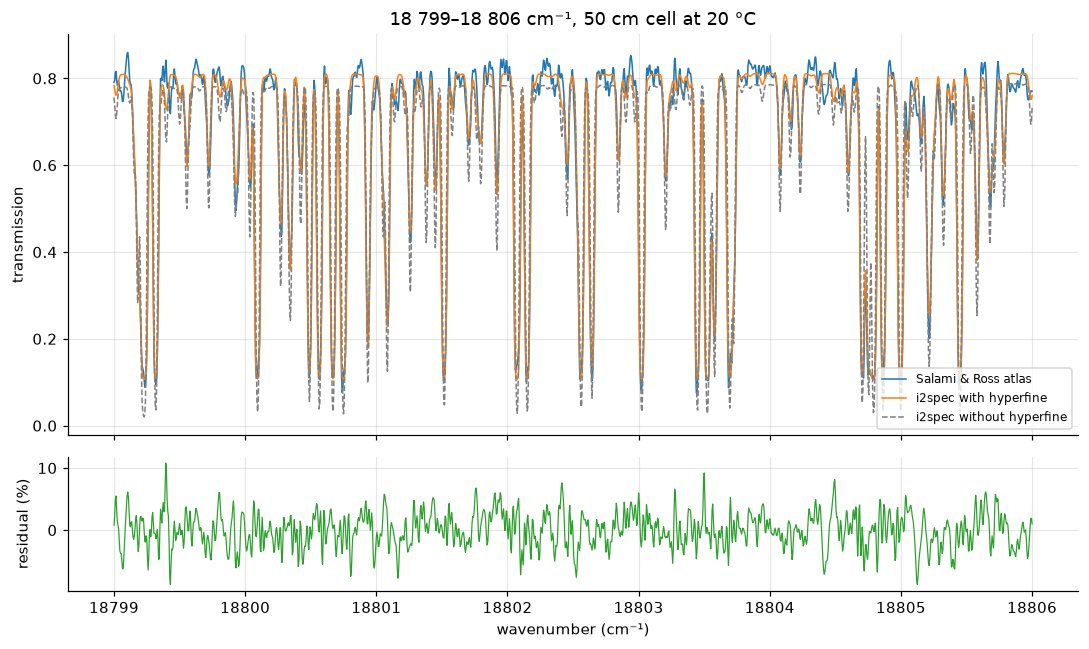

In [12]:
from i2spec.spectrum import convolve_gaussian, cross_section, hyperfine_patterns, number_density

T, lo, hi = 293.15, 18799.0, 18806.0
win = master.at(T, lo - 0.5, hi + 0.5)
grid = np.arange(lo - 0.3, hi + 0.3, 0.0005)
N = number_density(273.15 + 21.6, T) * 50.0
sigma = {"with hyperfine": cross_section(grid, win, T, hyperfine=hyperfine_patterns(mi, win, dJ=0)),
         "without hyperfine": cross_section(grid, win, T)}
trans = {k: convolve_gaussian(grid, np.exp(-s * N), 0.0147) for k, s in sigma.items()}
print(f"{len(win)} lines; column N = {N:.3e} cm⁻²")

atlas = EXTERNAL / "salami_ross_2005" / "salami_ross_2005_mmc1.txt"
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
if atlas.exists():
    d = np.loadtxt(atlas, skiprows=5)
    d = d[(d[:, 0] >= lo) & (d[:, 0] <= hi)]
    nu_a, t_a = d[:, 0], d[:, 1] / 100
    axes[0].plot(nu_a, t_a, "C0", lw=1, label="Salami & Ross atlas")
    for (name, t), style in zip(trans.items(), ("C1", "0.5")):
        tm = np.interp(nu_a, grid, t)
        A = np.column_stack([tm, tm * (nu_a - nu_a.mean()), np.ones_like(tm)])
        fit = A @ np.linalg.lstsq(A, t_a, rcond=None)[0]
        axes[0].plot(nu_a, fit, style, lw=1, ls="-" if name == "with hyperfine" else "--", label=f"i2spec {name}")
        print(f"{name:18s}: rms residual {100 * np.std(t_a - fit):.2f} % of transmission")
        if name == "with hyperfine":
            axes[1].plot(nu_a, 100 * (t_a - fit), "C2", lw=0.8)
    print(f"atlas noise, from second differences: {100 * np.std(np.diff(t_a, 2)) / np.sqrt(6):.2f} %")
else:
    for name, t in trans.items():
        axes[0].plot(grid, t, lw=1, label=f"i2spec {name}")
    print("Atlas file not found: showing the model only.")
axes[0].set(ylabel="transmission", title="18 799–18 806 cm⁻¹, 50 cm cell at 20 °C")
axes[0].legend(loc="lower right", fontsize=8)
axes[1].set(xlabel="wavenumber (cm⁻¹)", ylabel="residual (%)")
fig.tight_layout()

## 7. Continuum and absolute cross section

Absorption is continuous above the last bound B level, and A←X and C←X are continuous everywhere. i2spec follows Tellinghuisen (2011):

* energy-normalized continuum functions of his A and C potentials, and of the B potential with his inner wall;
* his transition moments.

The B←X part is counted only above the last level in the line list, so there is no gap and nothing is counted twice. The squares are Tellinghuisen's Table II at 35 °C.

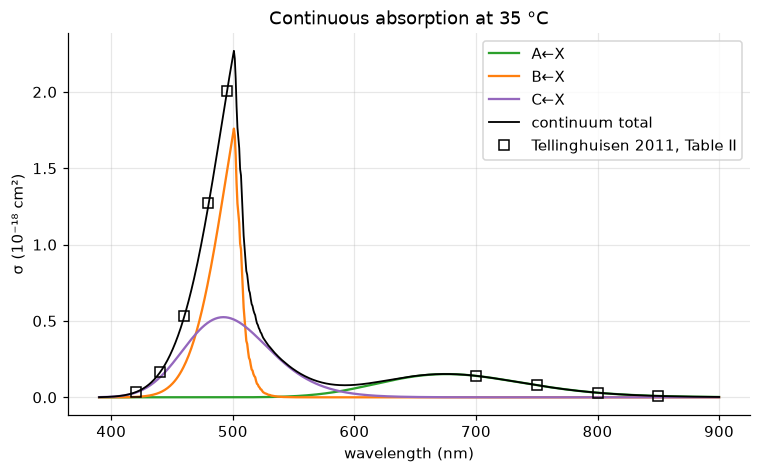

In [13]:
from i2spec.continuum import continuum_model

cont = continuum_model("127I2", master.upper_cut, T_max=600.0)
lam = np.linspace(390, 900, 700)
nu = 1e7 / lam
T = 308.15
fig, ax = plt.subplots()
for s, c in (("A", "C2"), ("B", "C1"), ("C", "C4")):
    ax.plot(lam, 1e18 * cont.cross_section(nu, T, states=(s,)), c, label=f"{s}←X")
ax.plot(lam, 1e18 * cont.cross_section(nu, T), "k", lw=1.2, label="continuum total")
table2 = {420: 8.83, 440: 43.02, 460: 139.57, 480: 332.99, 495: 523.97, 700: 37.07, 750: 20.65, 800: 7.79, 850: 2.26}
ax.plot(list(table2), [3.82353e-3 * v for v in table2.values()], "ks", mfc="none", ms=6, label="Tellinghuisen 2011, Table II")
ax.set(xlabel="wavelength (nm)", ylabel="σ (10⁻¹⁸ cm²)", title="Continuous absorption at 35 °C")
ax.legend()

Lines plus continuum, averaged over a 0.59 nm instrument function, against Spietz et al. (2006). This comparison has no free parameter.

* The lines are averaged linearly. With 1 bar of N₂ in their cell, saturation changes the apparent cross section by less than 1% at their column; `prototypes/compare_cross_sections.py` does the full treatment.
* Their 0.59 nm wavelength scale appears to run 0.1–0.15 nm long.
* The model follows Tellinghuisen's absolute scale, which is 3% above Spietz's σ(500 nm).

model / measured at 490–586 nm: mean 1.046


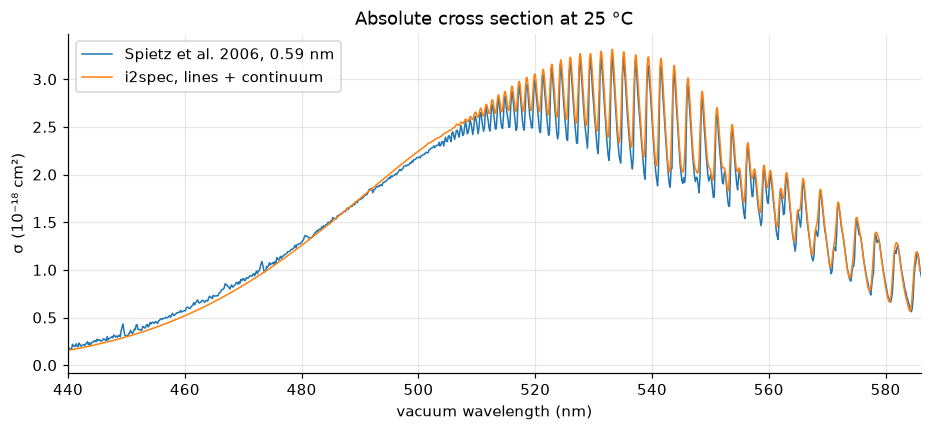

In [14]:
T = 298.0
lines = master.at(T)
edges = np.arange(1e7 / 592.0, 1e7 / 436.0, 0.2)
centres = (edges[1:] + edges[:-1]) / 2
sig = np.histogram(lines.nu, edges, weights=lines.S)[0] / 0.2 + cont.cross_section(centres, T)
lam_c = 1e7 / centres
lam_o = np.arange(440.0, 586.0, 0.1)
model = np.array([np.average(sig, weights=np.exp(-4 * np.log(2) * ((lam_c - l) / 0.59) ** 2)) for l in lam_o])

fig, ax = plt.subplots(figsize=(10, 4))
spietz = EXTERNAL / "spietz_2006" / "I2DOASref_0300.TXT"
if spietz.exists():
    rows = []
    for line in open(spietz, encoding="latin-1"):
        try:
            rows.append([float(v) for v in line.split()[:2]])
        except (ValueError, IndexError):
            pass
    ref = np.array([r for r in rows if len(r) == 2])
    ax.plot(ref[:, 0], 1e18 * ref[:, 1], "C0", lw=1, label="Spietz et al. 2006, 0.59 nm")
    sel = (ref[:, 0] > 490) & (ref[:, 0] < 586)
    ratio = np.interp(ref[sel, 0], lam_o, model) / ref[sel, 1]
    print(f"model / measured at 490–586 nm: mean {ratio.mean():.3f}")
ax.plot(lam_o, 1e18 * model, "C1", lw=1, label="i2spec, lines + continuum")
ax.set(xlabel="vacuum wavelength (nm)", ylabel="σ (10⁻¹⁸ cm²)", xlim=(440, 586), title="Absolute cross section at 25 °C")
ax.legend()

## 8. Where the published model stops working

The same checks show where the published parameters fail. These are the targets of the refit (Phase B):

* **B-state levels above v′ ≈ 44** are extrapolated and come out too low, by up to 2.2 cm⁻¹ at v′ = 53–55. The plot below shows each band's offset against the atlas (`prototypes/band_shifts_salami_ross.py`).
* **Isotope shifts** of ¹²⁹I₂ and ¹²⁷I¹²⁹I are 5–14 MHz off against BIPM (`docs/research/bipm-hyperfine-tables.md`).
* **B levels at 532 nm** are off by −6 to +6 MHz across v′ = 32–37.

The full evidence is in `docs/research/spectra-validation.md` and `docs/research/bipm-hyperfine-tables.md`.

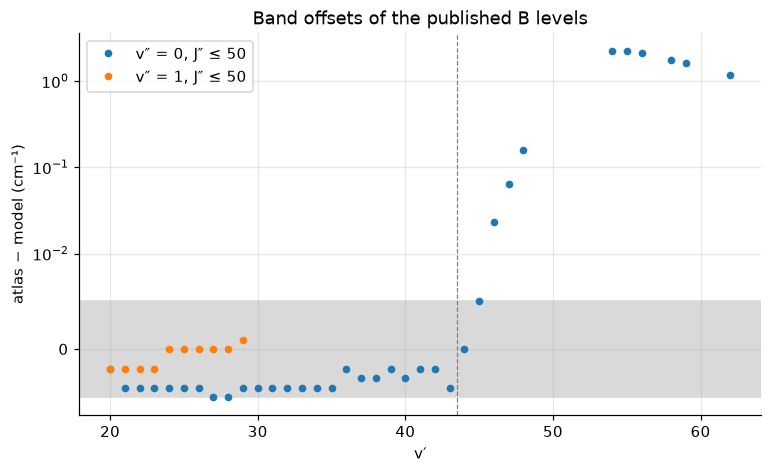

In [15]:
offsets = ROOT / "prototypes" / "out" / "band_shifts_salami_ross.txt"
if offsets.exists():
    b = np.loadtxt(offsets)
    fig, ax = plt.subplots()
    for vl, c in ((0, "C0"), (1, "C1")):
        ok = (b[:, 1] == vl) & (b[:, 3] >= 1.9)
        ax.plot(b[ok, 0], b[ok, 2], "o", color=c, ms=4, label=f"v″ = {vl}, J″ ≤ 50")
    ax.set_yscale("symlog", linthresh=0.01)
    ax.axvline(43.5, color="0.5", ls="--", lw=0.8)
    ax.axhspan(-0.005, 0.005, color="0.85", zorder=0)
    ax.set(xlabel="v′", ylabel="atlas − model (cm⁻¹)", title="Band offsets of the published B levels")
    ax.legend()
else:
    print("Run prototypes/band_shifts_salami_ross.py to produce the band offsets.")